In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
from skimage.io import imread
from skimage.segmentation import mark_boundaries
from skimage.feature import canny
from skimage.color import rgb2gray
from superpixel import SuperpixelExtractor

def test_single_image_all_algorithms(img_path):
    # algorithms = ["slic", "felzenszwalb", "quickshift", "watershed", "seeds"]
    algorithms = ["slic"]

    # 加载图像并转为 Tensor
    img = imread(img_path)
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float()  # [1, 3, H, W]

    # 归一化用于 mark_boundaries 和灰度处理
    img_for_vis = img / 255.0 if img.max() > 1 else img
    gray_img = rgb2gray(img_for_vis)
    canny_edges = canny(gray_img)

    plt.figure(figsize=(18, 10))

    # 显示原图
    plt.subplot(2, 4, 1)
    plt.imshow(img_for_vis)
    plt.title("Original Image")
    plt.axis('off')

    # 显示 Canny 边缘图
    plt.subplot(2, 4, 2)
    plt.imshow(canny_edges, cmap='gray')
    plt.title("Canny Edge Detection")
    plt.axis('off')

    for i, algo in enumerate(algorithms):
        print(f"Running {algo}...")
        try:
            extractor = SuperpixelExtractor(algo)
            start = time.time()
            _, n_masks, _, assigned = extractor(img_tensor)
            duration = time.time() - start

            segments = assigned[0].numpy()
            vis_image = mark_boundaries(img_for_vis, segments)

            # 注意索引从第3个 subplot 开始
            plt.subplot(2, 4, i + 3)
            plt.imshow(vis_image)
            plt.title(f"{algo.upper()} ({n_masks[0]} masks)\nTime: {duration:.2f}s")
            plt.axis('off')
        except Exception as e:
            print(f"[ERROR] {algo}: {e}")

    plt.tight_layout()
    plt.show()

# 调用主函数
image_path = "/home/liw324/code/Segment/LKSeg/data/LoveDA/Train/Rural/images_png/0.png"
test_single_image_all_algorithms(image_path)

Running slic...
Parameters dict at beginning of init slic


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
from skimage.io import imread
from skimage.segmentation import mark_boundaries
from skimage.feature import canny
from skimage.color import rgb2gray
from superpixel import SuperpixelExtractor
# from superpixel_configs import felzenszwalb_parameters_dict, slic_parameters_dict, quickshift_parameters_dict, watershed_parameters_dict, seeds_parameters_dict

slic_parameters_dict = {
    "n_segments": 200,  # 100  # The (approximate) number of labels in the segmented output image.
    "compactness": 10,
    # Balances color proximity and space proximity. Higher values give more weight to space proximity, making superpixel shapes more square/cubic. We recommend exploring possible values on a log scale, e.g., 0.01, 0.1, 1, 10, 100, before refining around a chosen value.
    "sigma": 1,  # 0,  # Width of Gaussian smoothing kernel for pre-processing for each dimension of the image.
    "start_label": 0,
    "min_size_factor": 0.5,  # Proportion of the minimum segment size to be removed with respect to the supposed segment size `depth*width*height/n_segments`
    "max_num_iter": 10,  # Maximum number of iterations of k-means
    "enforce_connectivity": True,  # Whether the generated segments are connected or not
}

# felzenszwalb_parameters_dict = {
#     "scale": 600,  # Higher scale means less and larger segments
#     "sigma": 0.8,  # is the diameter of a Gaussian kernel, used for smoothing the image prior to segmentation.
#     "min_size": 400,  # Minimum component size. Enforced using postprocessing.
# }

def test_single_image_all_algorithms(img_path):
    # scale_list = [10, 50, 100, 300, 600]
    # sigma_list = [0.2, 0.4, 0.6, 0.8, 1]
    
    scale_list = [10, 20, 50, 100, 200]
    sigma_list = [1, 5, 10, 20, 100]

    img = imread(img_path)
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float()

    img_for_vis = img / 255.0 if img.max() > 1 else img
    
    extractor = SuperpixelExtractor("slic")
    for scale in scale_list:
        cols = len(sigma_list)
        rows = 1
        plt.figure(figsize=(4 * cols, 4 * rows))
        for idx, sigma in enumerate(sigma_list):
            print(f"n={scale}, c={sigma}")
            felz_params = slic_parameters_dict.copy()
            felz_params["n_segments"] = scale
            felz_params["compactness"] = sigma
            try:
                _, n_masks, _, assigned = extractor(img_tensor, felz_params)
                segments = assigned[0].numpy()
                vis_image = mark_boundaries(img_for_vis, segments)
                plt.subplot(rows, cols, idx + 1)
                plt.imshow(vis_image)
                plt.title(f"n={scale}, c={sigma}")
                plt.axis('off')
            except Exception as e:
                print(f"[ERROR] n={scale}, c={sigma}: {e}")

        plt.tight_layout()
        plt.savefig(f"out1/n_segments={scale}.png", dpi=300, bbox_inches='tight')
        plt.close()


# 调用主函数
image_id = "235"
image_path = f"/home/liw324/code/Segment/LKSeg/data/EarthVQA/Train/images_png/{image_id}.png"
test_single_image_all_algorithms(image_path)

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
from skimage.io import imread
from skimage.segmentation import mark_boundaries
from skimage.feature import canny
from skimage.color import rgb2gray
from superpixel import SuperpixelExtractor
# from superpixel_configs import felzenszwalb_parameters_dict, slic_parameters_dict, quickshift_parameters_dict, watershed_parameters_dict, seeds_parameters_dict

slic_parameters_dict = {
    "n_segments": 200,  # 100  # The (approximate) number of labels in the segmented output image.
    "compactness": 10,
    # Balances color proximity and space proximity. Higher values give more weight to space proximity, making superpixel shapes more square/cubic. We recommend exploring possible values on a log scale, e.g., 0.01, 0.1, 1, 10, 100, before refining around a chosen value.
    "sigma": 1,  # 0,  # Width of Gaussian smoothing kernel for pre-processing for each dimension of the image.
    "start_label": 0,
    "min_size_factor": 0.5,  # Proportion of the minimum segment size to be removed with respect to the supposed segment size `depth*width*height/n_segments`
    "max_num_iter": 10,  # Maximum number of iterations of k-means
    "enforce_connectivity": True,  # Whether the generated segments are connected or not
}

# felzenszwalb_parameters_dict = {
#     "scale": 600,  # Higher scale means less and larger segments
#     "sigma": 0.8,  # is the diameter of a Gaussian kernel, used for smoothing the image prior to segmentation.
#     "min_size": 400,  # Minimum component size. Enforced using postprocessing.
# }

def test_single_image_all_algorithms(img_path):
    scale_list = [10, 50, 100, 300, 600]
    sigma_list = [0.2, 0.4, 0.6, 0.8, 1]

    img = imread(img_path)
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float()

    img_for_vis = img / 255.0 if img.max() > 1 else img
    
    extractor = SuperpixelExtractor("felzenszwalb")
    for scale in scale_list:
        cols = len(sigma_list)
        rows = 1
        plt.figure(figsize=(4 * cols, 4 * rows))
        for idx, sigma in enumerate(sigma_list):
            print(f"scale={scale}, sigma={sigma}")
            felz_params = slic_parameters_dict.copy()
            felz_params["scale"] = scale
            felz_params["sigma"] = sigma
            try:
                _, n_masks, _, assigned = extractor(img_tensor, felz_params)
                segments = assigned[0].numpy()
                vis_image = mark_boundaries(img_for_vis, segments)
                plt.subplot(rows, cols, idx + 1)
                plt.imshow(vis_image)
                plt.title(f"scale={scale}, sigma={sigma}")
                plt.axis('off')
            except Exception as e:
                print(f"[ERROR] scale={scale}, sigma={sigma}: {e}")

        plt.tight_layout()
        plt.savefig(f"out1/scale={scale}.png", dpi=300, bbox_inches='tight')
        plt.close()


# 调用主函数
image_id = "235"
image_path = f"/home/liw324/code/Segment/LKSeg/data/EarthVQA/Train/images_png/{image_id}.png"
test_single_image_all_algorithms(image_path)

In [3]:
from PIL import Image
import os

# 图像路径列表
n_segments_list = [10, 20, 50, 100, 200]
# scale_list = [10, 50, 100, 300, 600]

base_path = "out1"
image_paths = [os.path.join(base_path, f"n_segments={n}.png") for n in n_segments_list]

# 加载图像
images = [Image.open(p) for p in image_paths]

# 计算拼接后尺寸
widths, heights = zip(*(img.size for img in images))
max_width = max(widths)
total_height = sum(heights)

# 创建空白图像并拼接
combined_image = Image.new("RGB", (max_width, total_height))
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.height

# 保存
output_path = os.path.join(base_path, "combined_vertical.png")
combined_image.save(output_path)
print(f"拼接图像已保存：{output_path}")

拼接图像已保存：out1/combined_vertical.png


Running slic...
Parameters dict at beginning of init slic
torch.Size([154, 1024, 1024]) [154] torch.Size([1, 1024, 1024]) torch.Size([1, 1024, 1024])
tensor([True]) tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 14

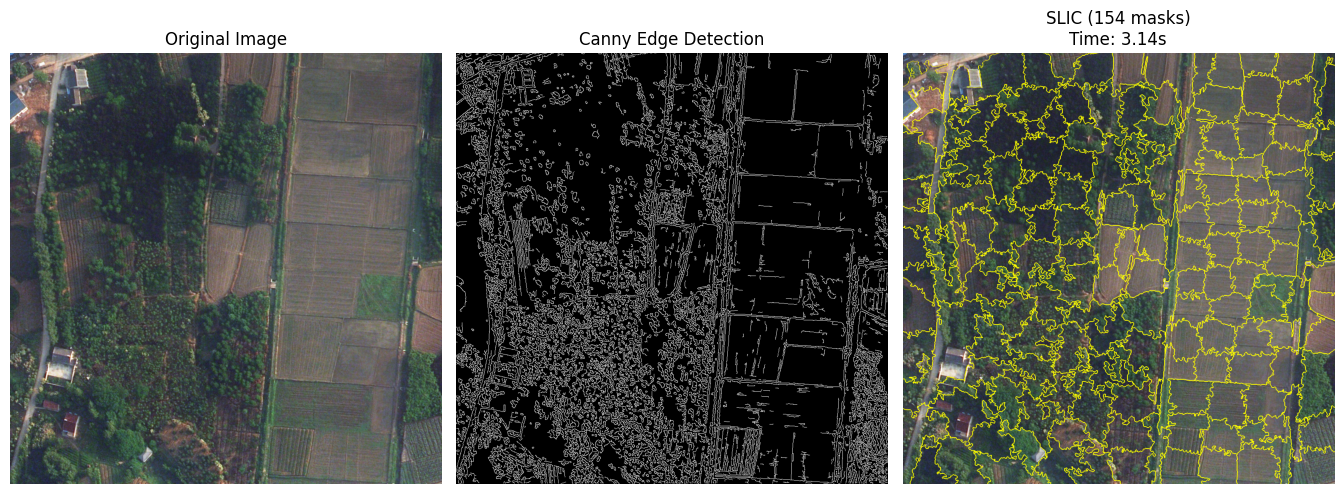

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
from skimage.io import imread
from skimage.segmentation import mark_boundaries
from skimage.feature import canny
from skimage.color import rgb2gray
from superpixel import SuperpixelExtractor

def test_single_image_all_algorithms(img_path):
    # algorithms = ["slic", "felzenszwalb", "quickshift", "watershed", "seeds"]
    algorithms = ["slic"]

    # 加载图像并转为 Tensor
    img = imread(img_path)
    if img.shape[-1] > 3:
        img = img[:, :, :3]
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float()  # [1, 3, H, W]

    # 归一化用于 mark_boundaries 和灰度处理
    img_for_vis = img / 255.0 if img.max() > 1 else img
    gray_img = rgb2gray(img_for_vis)
    canny_edges = canny(gray_img)

    plt.figure(figsize=(18, 10))

    # 显示原图
    plt.subplot(2, 4, 1)
    plt.imshow(img_for_vis)
    plt.title("Original Image")
    plt.axis('off')

    # 显示 Canny 边缘图
    plt.subplot(2, 4, 2)
    plt.imshow(canny_edges, cmap='gray')
    plt.title("Canny Edge Detection")
    plt.axis('off')

    for i, algo in enumerate(algorithms):
        print(f"Running {algo}...")
        try:
            extractor = SuperpixelExtractor(algo)
            start = time.time()
            _, n_masks, _, assigned = extractor(img_tensor)
            pred_masks_batch, n_pred_masks, covered_pixels_batch, assigned_masks_batch = extractor(img_tensor)
            print(pred_masks_batch.shape, n_pred_masks, covered_pixels_batch.shape, assigned_masks_batch.shape)
            print(covered_pixels_batch.unique(), assigned_masks_batch.unique())
            
            duration = time.time() - start

            segments = assigned[0].numpy()
            vis_image = mark_boundaries(img_for_vis, segments)

            # 注意索引从第3个 subplot 开始
            plt.subplot(2, 4, i + 3)
            plt.imshow(vis_image)
            plt.title(f"{algo.upper()} ({n_masks[0]} masks)\nTime: {duration:.2f}s")
            plt.axis('off')
        except Exception as e:
            print(f"[ERROR] {algo}: {e}")

    plt.tight_layout()
    plt.show()

# 调用主函数
image_path = "/home/liw324/code/Segment/LKSeg/data/LoveDA/Train/Rural/images_png/0.png"
test_single_image_all_algorithms(image_path)